In [2]:
# Cài đặt (nếu chưa có)
# !pip install lifelines

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

# Load dữ liệu từ Buổi 3 (đã có xác suất Churn)
df = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_churn.csv')

# Convert ngày tháng
df['created_date'] = pd.to_datetime(df['created_date'])
df['last_active_date'] = pd.to_datetime(df['last_active_date'])

print(f"Data Loaded: {df.shape}")
df.head()

Data Loaded: (79949, 13)


,id,full_name,created_date,last_active_date,Customer_Segment_RFM,occupation,CLV_12_months,CLV_Segment,Churn_Prob,Recency_Days,exit,age,balance
0,1,Đặng Văn Vũ,2025-02-27,2025-04-03,Loyal/Active Users,Chủ Doanh nghiệp nhỏ,8.294699e+05,Mid Value,0.000226,90,False,55,177306004
1,2,Bùi Hữu Phúc,2021-07-29,2025-05-14,Loyal/Active Users,Nội trợ/Sinh viên,9.998768e+04,Low Value,0.665092,49,False,45,1927416
2,3,Lê Văn Mai,2021-03-03,2021-09-10,Churned (Inactive),Chủ Doanh nghiệp nhỏ,5.317629e+01,Low Value,0.000541,1391,False,44,304931745
3,4,Dương Trần Nhiên,2022-02-12,2025-03-04,VIP At Risk,Chủ Doanh nghiệp nhỏ,2.525261e+06,High Value,0.008213,120,False,44,50615501
4,5,Dương Thu Linh,2022-07-24,2022-08-06,Churned (Inactive),Giáo viên/Giảng viên,3.084639e+03,Low Value,0.331101,1061,False,77,40532432


In [3]:
# 1. Tính toán T (Duration) và E (Event)
# T: Thời gian gắn bó (tính bằng tháng cho dễ nhìn)
df['T_months'] = (df['last_active_date'] - df['created_date']).dt.days / 30

# E: Sự kiện exit
df['E'] = df['exit'].astype(int)

# 2. Xử lý dữ liệu nhiễu
# CoxPH yêu cầu T > 0. Nếu ai đó tạo TK xong đi luôn trong ngày (T=0), ta gán T=0.1
df['T_months'] = df['T_months'].apply(lambda x: x if x > 0 else 0.1)

print("Mẫu dữ liệu Survival (T, E):")
print(df[['full_name', 'T_months', 'E', 'exit']].head())

Mẫu dữ liệu Survival (T, E):
          full_name   T_months  E   exit
0       Đặng Văn Vũ   1.166667  0  False
1      Bùi Hữu Phúc  46.166667  0  False
2        Lê Văn Mai   6.366667  0  False
3  Dương Trần Nhiên  37.200000  0  False
4    Dương Thu Linh   0.433333  0  False


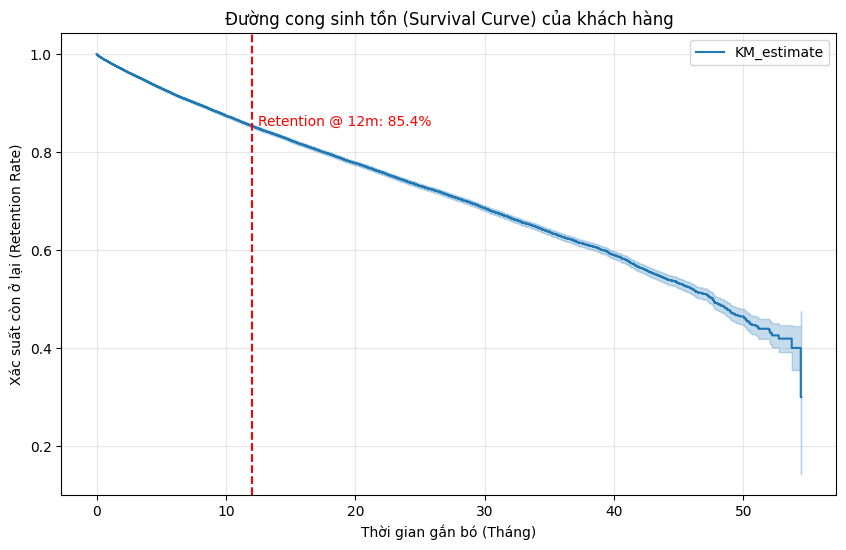

In [4]:
# Khởi tạo Kaplan-Meier Fitter
kmf = KaplanMeierFitter()

# Fit dữ liệu
kmf.fit(durations=df['T_months'], event_observed=df['E'])

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Đường cong sinh tồn (Survival Curve) của khách hàng')
plt.xlabel('Thời gian gắn bó (Tháng)')
plt.ylabel('Xác suất còn ở lại (Retention Rate)')
plt.grid(True, alpha=0.3)

# Thêm đường tham chiếu: Tại tháng 12, còn bao nhiêu %?
retention_12m = kmf.predict(12)
plt.axvline(x=12, color='red', linestyle='--')
plt.text(12.5, retention_12m, f'Retention @ 12m: {retention_12m:.1%}', color='red')

plt.show()

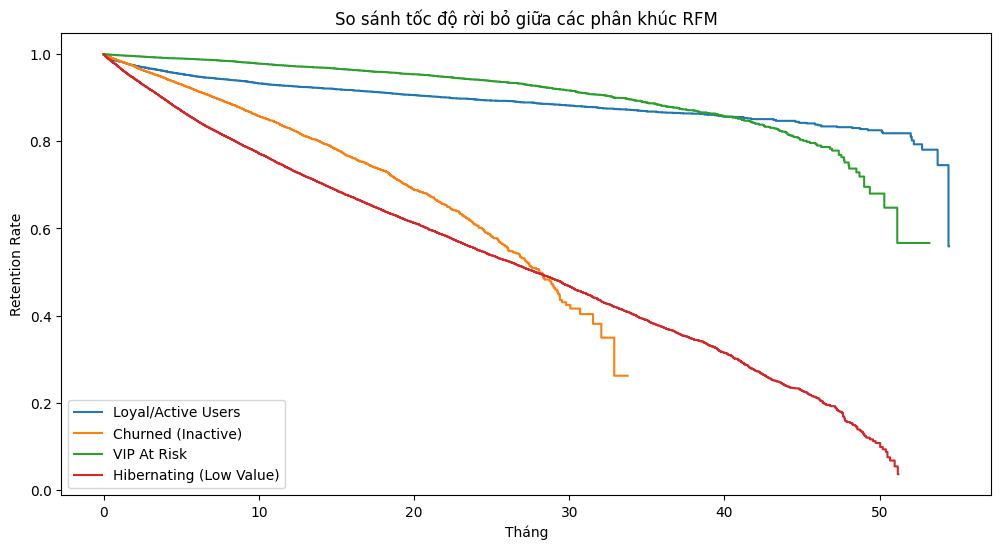

In [5]:
# So sánh theo phân khúc RFM
plt.figure(figsize=(12, 6))

segments = df['Customer_Segment_RFM'].unique()

for segment in segments:
    mask = df['Customer_Segment_RFM'] == segment
    # Chỉ vẽ nếu nhóm đó có dữ liệu
    if mask.sum() > 0:
        kmf.fit(df[mask]['T_months'], df[mask]['E'], label=str(segment))
        kmf.plot_survival_function(ci_show=False) # Tắt khoảng tin cậy cho đỡ rối

plt.title('So sánh tốc độ rời bỏ giữa các phân khúc RFM')
plt.xlabel('Tháng')
plt.ylabel('Retention Rate')
plt.show()

In [7]:
missing_cols = ['credit_sco', 'nums_service']

# Kiểm tra xem có cột nào thiếu không
if not set(missing_cols).issubset(df.columns):
    print("⚠️ Đang khôi phục các cột thiếu từ dữ liệu gốc...")
    try:
        # Load lại file gốc
        df_origin = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\bank_churn_dataset_80k.csv')
        
        # Xác định cột cần lấy (chỉ lấy những cột thực sự thiếu)
        cols_to_merge = ['id'] + [col for col in missing_cols if col not in df.columns]
        
        # Merge vào dataframe hiện tại
        df = df.merge(df_origin[cols_to_merge], on='id', how='left')
        print(f"✅ Đã khôi phục thành công: {cols_to_merge[1:]}")
    except FileNotFoundError:
        print("❌ Lỗi: Không tìm thấy file gốc bank_churn_dataset_80k.csv")

⚠️ Đang khôi phục các cột thiếu từ dữ liệu gốc...
✅ Đã khôi phục thành công: ['credit_sco', 'nums_service']


--- CoxPH Model Summary ---


AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 79949 total observations, 65549 right-censored observations>
             duration col = 'T_months'
                event col = 'E'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 79949
number of events observed = 14400
   partial log-likelihood = -142661.75
         time fit was run = 2025-12-06 00:34:36 UTC

---
                                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                 
age                                      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
credit_sco                               -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
balance                                  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
nums_service                             -0.17      0.84      0.01           -0.18           -0.16                0.83                0.85
Recency_Days                              0.00      1.00      0.00            0.00            0.00                1.00                1.00
occupation_Giáo viên/Giảng viên           0.34      1.40      0.04            0.25            0.42                1.28                1.53
occupation_Hưu trí                        0.64      1.90      0.04            0.56            0.72                1.75                2.06
occupation_Kinh doanh/Bán hàng            0.26      1.30      0.04            0.17            0.35                1.19                1.42
occupation_Kế toán/Tài chính              0.30      1.35      0.05            0.21            0.39                1.23                1.47
occupation_Kỹ sư/Chuyên viên IT          -0.52      0.60      0.06           -0.64           -0.40                0.53                0.67
occupation_Lao động phổ thông             0.69      1.98      0.04            0.60            0.77                1.83                2.15
occupation_Nhân viên văn phòng/Công chức  0.51      1.66      0.04            0.42            0.59                1.53                1.81
occupation_Nội trợ/Sinh viên              0.79      2.21      0.04            0.71            0.87                2.04                2.39
occupation_Quản lý/Lãnh đạo              -0.91      0.40      0.08           -1.07           -0.75                0.34                0.47

                                          cmp to      z      p  -log2(p)
covariate                                                               
age                                         0.00  -4.72 <0.005     18.71
credit_sco                                  0.00 -32.87 <0.005    784.70
balance                                     0.00 -44.03 <0.005       inf
nums_service                                0.00 -31.00 <0.005    698.36
Recency_Days                                0.00  28.76 <0.005    601.81
occupation_Giáo viên/Giảng viên             0.00   7.60 <0.005     44.90
occupation_Hưu trí                          0.00  15.36 <0.005    174.47
occupation_Kinh doanh/Bán hàng              0.00   5.82 <0.005     27.35
occupation_Kế toán/Tài chính                0.00   6.60 <0.005     34.47
occupation_Kỹ sư/Chuyên viên IT             0.00  -8.61 <0.005     56.90
occupation_Lao động phổ thông               0.00  16.50 <0.005    200.82
occupation_Nhân viên văn phòng/Công chức    0.00  11.87 <0.005    105.54
occupation_Nội trợ/Sinh viên                0.00  19.18 <0.005    270.03
occupation_Quản lý/Lãnh đạo                 0.00 -10.94 <0.005     90.12
---
Concordance = 0.78
Partial AIC = 285351.49
log-likelihood ratio test = 14741.85 on 14 df
-log2(p) of ll-ratio test = inf

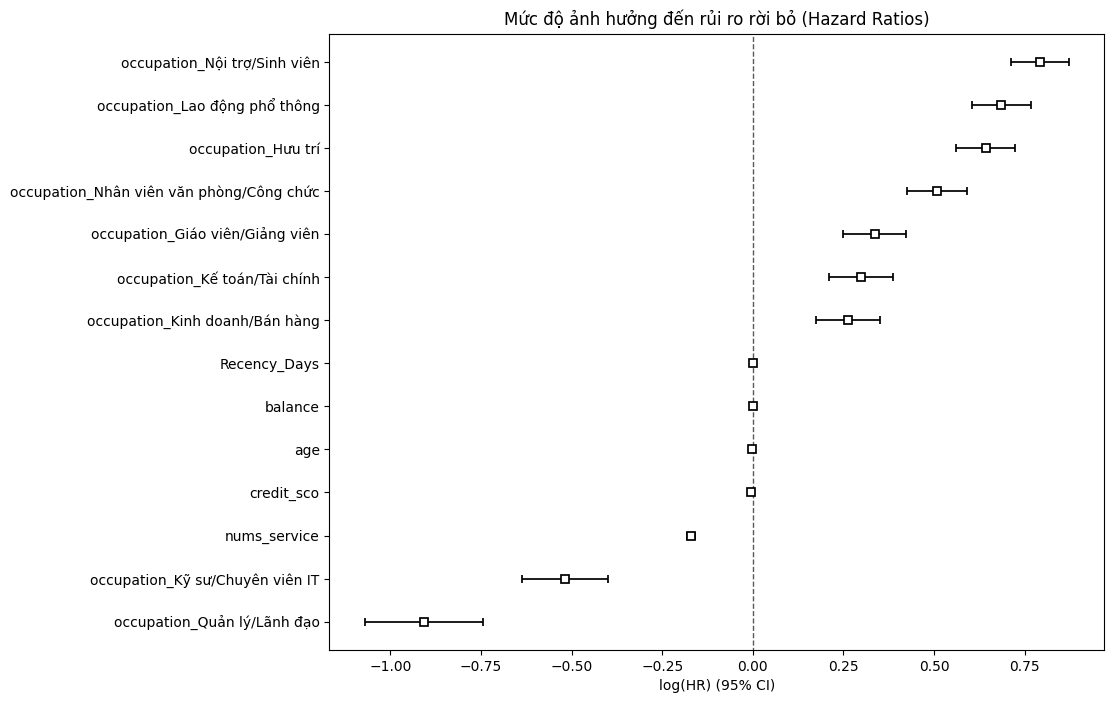

In [9]:
# 1. Chuẩn bị dữ liệu cho CoxPH
# Chọn features quan trọng (tránh chọn quá nhiều gây nhiễu/lỗi cộng tuyến)
cox_cols = [
    'T_months', 'E',            # Bắt buộc
    'age', 'credit_sco',        # Nhân khẩu học
    'balance', 'nums_service',  # Tài chính
    'Recency_Days',             # Hành vi
    'occupation'                # Category (cần mã hóa)
]

df_cox = df[cox_cols].copy()

# 2. Mã hóa biến Category (One-Hot Encoding) cho 'occupation'
df_cox = pd.get_dummies(df_cox, columns=['occupation'], drop_first=True)

# 3. Fit Model
cph = CoxPHFitter(penalizer=0.01) # penalizer giúp mô hình ổn định hơn
cph.fit(df_cox, duration_col='T_months', event_col='E')

# 4. Xem kết quả
print("--- CoxPH Model Summary ---")
cph.print_summary()

# 5. Vẽ biểu đồ tác động (Hazard Ratios)
plt.figure(figsize=(10, 8))
cph.plot()
plt.title("Mức độ ảnh hưởng đến rủi ro rời bỏ (Hazard Ratios)")
plt.show()

In [10]:
# 1. Dự báo Partial Hazard (Rủi ro tương đối)
# Giá trị càng cao -> Rủi ro rời bỏ càng lớn so với mức trung bình
df['Survival_Risk_Score'] = cph.predict_partial_hazard(df_cox)

# 2. Dự báo số tháng sống sót trung bình còn lại (Median Survival Time)
# Lưu ý: Tính toán này khá nặng nếu data lớn.
# Nếu thấy lâu quá có thể bỏ qua dòng dưới.
# df['Predicted_Months_Left'] = cph.predict_median(df_cox)

print("Top 5 Khách hàng có rủi ro rời bỏ cao nhất (theo Survival Model):")
print(df.sort_values('Survival_Risk_Score', ascending=False)[['full_name', 'Survival_Risk_Score', 'Recency_Days']].head())

Top 5 Khách hàng có rủi ro rời bỏ cao nhất (theo Survival Model):
            full_name  Survival_Risk_Score  Recency_Days
7909   Đặng Kim Hoàng            26.322244          1162
41525   Phạm Anh Phúc            24.653007          1222
33223   Mai Thanh Ánh            24.205059          1459
3538   Phạm Hoàng Anh            22.826494          1606
65610       Lê Thu Vũ            22.786324          1462


In [11]:
cols_to_save = [
    'id', 'full_name', 'created_date', 'last_active_date',
    'Customer_Segment_RFM', 'occupation',
    'CLV_12_months', 'CLV_Segment',      # Từ Buổi 2
    'Churn_Prob',                        # Từ Buổi 3
    'Survival_Risk_Score', 'T_months', 'E', # Mới từ Buổi 4
    'exit', 'age', 'balance', 'Recency_Days' # Features gốc
]

df[cols_to_save].to_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_survival.csv', index=False)
print("Đã lưu file: processed_bank_data_survival.csv")

Đã lưu file: processed_bank_data_survival.csv
